#**EXPERIMENT-6** -StudentAcademicPerformance Dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

In [26]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/StudentAcamdemicPerformance.csv")
print("Shape:", df.shape)
print("Columns:", df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (480, 17)
Columns: Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')


In [27]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:\n\n",df.isna().sum())

Duplicate rows: 2

Missing values:

 gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64


In [28]:
# Clean Target Column
df['Class'] = df['Class'].astype(str)
df['Class'] = df['Class'].str.strip()
df['Class'] = df['Class'].str.upper()
print("Unique Classes:", df['Class'].unique())

Unique Classes: ['M' 'L' 'H']


In [29]:
# Convert Class to numeric
df['Class'] = df['Class'].map({'L':0, 'M':1, 'H':2})
print("NaN in Class:", df['Class'].isna().sum())

NaN in Class: 0


In [30]:
df = pd.get_dummies(df, drop_first=True) # Convert Categorical to Numeric
X = df[['raisedhands', 'VisITedResources', 'Discussion']] # Select 3 Numeric Features for 3D
Y = df['Class']

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.3, stratify=Y, random_state=42) #Train Test Split

In [32]:
#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
# Logistic Regression with Cross Validation
model = LogisticRegressionCV(Cs=10,cv=5,penalty='l2',solver='lbfgs',max_iter=2000,multi_class='multinomial',random_state=42)
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1908: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegressionCV(cv=5, max_iter=2000, multi_class='multinomial',
                     random_state=42)

In [34]:
#evalution
Y_pred = model.predict(X_test)
print("Best C selected:", model.C_)
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Best C selected: [0.04641589 0.04641589 0.04641589]
Accuracy: 0.5486111111111112

Confusion Matrix:
 [[25 13  0]
 [15 31 17]
 [ 1 19 23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.63        38
           1       0.49      0.49      0.49        63
           2       0.57      0.53      0.55        43

    accuracy                           0.55       144
   macro avg       0.56      0.56      0.56       144
weighted avg       0.55      0.55      0.55       144



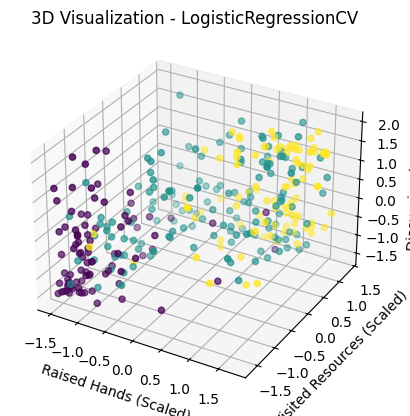

In [35]:
#3D Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train[:,0],X_train[:,1],X_train[:,2],c=Y_train,)
ax.set_xlabel("Raised Hands (Scaled)")
ax.set_ylabel("Visited Resources (Scaled)")
ax.set_zlabel("Discussion (Scaled)")
ax.set_title("3D Visualization - LogisticRegressionCV")
plt.show()